# Simulation of a positron-induced Muon Source

In [157]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

<center>
    <img src="Feynman_Diagram.svg" width="400" style="filter: invert(100%)">
</center>

\begin{split}
iM &= \overline{u}_{r'}(k) (ie\gamma^{\mu}) v_{s'}(k') \left( \frac{-i\eta_{\mu\nu}}{s} \right) \overline{v}_{s}(p') (ie\gamma^{\nu}) u_{r}(p) \\
   &= \frac{ie^2}{s} (\overline{u}_{r'}(k) \gamma^{\mu} v_{s'}(k') \overline{v}_{s}(p') \gamma_{\mu} u_{r}(p))
\end{split}


$\providecommand{\slashed}[1]{#1 \kern-0.5em /}$
$|\overline{M}|^2 = \frac{1}{4} \sum_{spins} M M^* = \frac{e^4}{4 s^2} Tr((\slashed{k}'-m) \gamma^\nu (\slashed{k}+m) \gamma^\mu) Tr((\slashed{p}+m) \gamma_\nu (\slashed{p}'-m) \gamma_\mu)$

$\providecommand{\slashed}[1]{#1 \kern-0.5em /}$

$Tr((\slashed{k}'-m) \gamma^\nu (\slashed{k}+m) \gamma^\mu) = 4 (k^\mu k'^\nu + k^\nu k'^\mu - (k \cdot k' + m_\mu^2) \eta^{\nu\mu})$

$Tr((\slashed{p}+m) \gamma_\nu (\slashed{p}'+m) \gamma_\mu) = 4 (p_\mu p'_\nu + p_\nu p'_\mu - (p \cdot p' + m_e^2) \eta_{\nu\mu})$


(Note: $m_\mu^2$ is not Einstein indexing)

$|\overline{M}|^2 = \frac{8 e^4}{s^2} ((k \cdot p)(k' \cdot p') + (k \cdot p')(k' \cdot p) + m_e^2 (k \cdot k') + m_\mu^2 (p \cdot p') + 2 m_e^2 m_\mu^2)$

$m_e$ negligible ?

Kinematic

$ s = (p + p')^2 = 2 m_e^2 + 2 p \cdot p' \Rightarrow p \cdot p' = \frac{s}{2} - m_e^2 $

$ k \cdot k' = \frac{s}{2} - m_\mu^2$

$ p \cdot k = $

$ p \cdot k' = $

If $m_e = 0$

$\left( \frac{d\sigma}{d\omega} \right)_{CM} = \frac{e^4}{64 \pi^2 s} \sqrt{\left(1 - \frac{4 m_\mu^2}{s} \right)} \left(\left(1 + \frac{4 m_\mu^2}{s} \right) + \left(1 - \frac{4 m_\mu^2}{s} \right) \cos{\theta}^2 \right) $

$(p, 0, 0, p)$

$p_\mu p^\mu = m_\gamma^2 = 0 = E^2 - p^2$

## Physical constants and Cross section

In [158]:
# Physical constants
mass_e = 0.00051099895069  # GeV, electron mass
mass_mu = 0.1056583755     # GeV, muon mass
alpha = 1/137               # fine-structure constant
conversion_factor = 0.3894  # (ħ*c)^2 in mbarn*GeV for cross section conversion

# Differential cross section in CM frame
def cross_section(s, theta):
    ratio = 4 * mass_mu**2 / s
    return ((np.pi * alpha**2)/ (2 * s)) * np.sqrt(1 - ratio) * (1 + ratio + (1 - ratio) * np.cos(theta)**2)

# Normalized angular distribution
def cross_section_norm(s, cos):  
    ratio = 4 * mass_mu**2 / s
    beta = np.sqrt(1 - ratio)
    return 3 / (4*(3 - beta**2)) * (1 + cos**2 + (1 - beta**2) * (1 - cos**2))

## Graphical Settings

In [159]:
def plot_theory(s):
    cos_range = np.linspace(-1, 1, 100)
    plt.plot(cos_range, cross_section_norm(s, cos_range), label="Normalized theory", linewidth=1.5, linestyle='--', color="red")

In [160]:
def plot_data(data):
    # Monte Carlo histogram (normalized)
    n_bins = 25
    pdf, bin_edges, _ = plt.hist(data, bins=n_bins, density=True, range=(-1, 1), 
             histtype='step', color='blue', label='Monte Carlo data', linewidth=1.5)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.
    bin_width = bin_edges[1] - bin_edges[0]
    
    # Poissonian error bars for normalized density
    pdf_err = np.sqrt(pdf / (len(data) * bin_width))

    plt.errorbar(bin_centers, pdf, yerr=pdf_err, fmt='none', ecolor='blue', linewidth=1,
                 alpha=0.6, capsize=2, label="Statistical uncertainty")
    
    y_min = np.min(pdf - pdf_err)
    y_max = np.max(pdf + pdf_err)
    margin = (y_max - y_min) * 0.2
    plt.ylim(y_min - margin, y_max + margin)

## Angular distribution of the Differential Cross section

In [161]:
# Threshold energy for muon pair production
E_threshold = 2*mass_mu  
print('Threshold sqrt(s) is:', E_threshold, 'GeV')

E_percent_increase = 0.05
E_fixed = E_threshold * (1 + E_percent_increase) 
print('sqrt(s) fixed at:', E_fixed, 'GeV, ', E_percent_increase * 100, r'% above threshold')

s = E_fixed**2

# Beam energy in lab frame
beam_energy = (s - 2 * mass_e**2) / (2 * mass_e)
print('Beam energy: ', beam_energy, 'GeV')

Threshold sqrt(s) is: 0.211316751 GeV
sqrt(s) fixed at: 0.22188258855 GeV,  5.0 % above threshold
Beam energy:  48.171684888311866 GeV


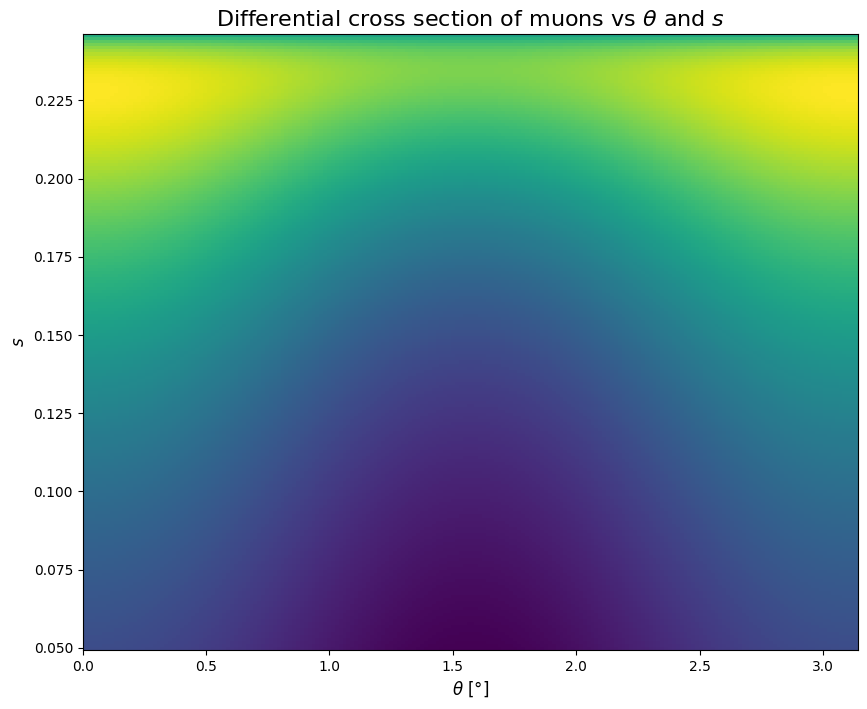

In [162]:
s_space = np.linspace(s, 5 * s, 200, endpoint=True)

xv, yv = np.meshgrid(l, s_space)

plt.figure(figsize=(10, 8))
plt.imshow(cross_section(yv, xv), extent=[0, np.pi, s, 5*s], aspect='auto')
plt.xlabel(r"$\theta$ [°]", fontsize=12)
plt.ylabel(r"$s$", fontsize=12)
plt.title(r"Differential cross section of muons vs $\theta$ and $s$", fontsize=16)
plt.show()

## Monte Carlo simulation

In [163]:
def montecarlo(n):
    # Generate random uniform values for cos(theta)
    cos = np.random.uniform(-1, 1, n)

    # Generate random numbers for acceptance-rejection method
    y = np.random.uniform(0, 1, n)       # 1 o cross_section_norm(s, 1)

    # Select accepted events
    accepted = cos[y < cross_section_norm(s, cos)]
    print("Accepted events: ", len(accepted))
    
    return accepted

Accepted events:  49610


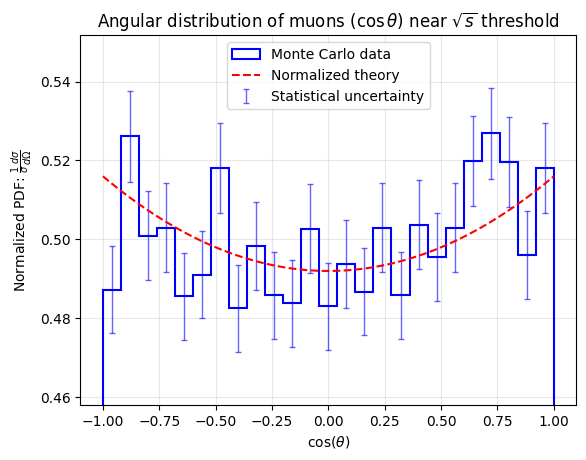

In [168]:
n = 100000

cos = montecarlo(n)

# Random azimuthal angle in CM frame
phi = np.random.uniform(0, 2*np.pi, len(cos))




plot_data(cos)
plot_theory(s)

plt.xlabel(r"$\cos(\theta)$")
plt.ylabel(r"Normalized PDF: $\frac{1}{\sigma}\frac{d\sigma}{d\Omega}$")
plt.title(r"Angular distribution of muons ($\cos \theta$) near $\sqrt{s}$ threshold")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

ValueError: x and y must have the same length.

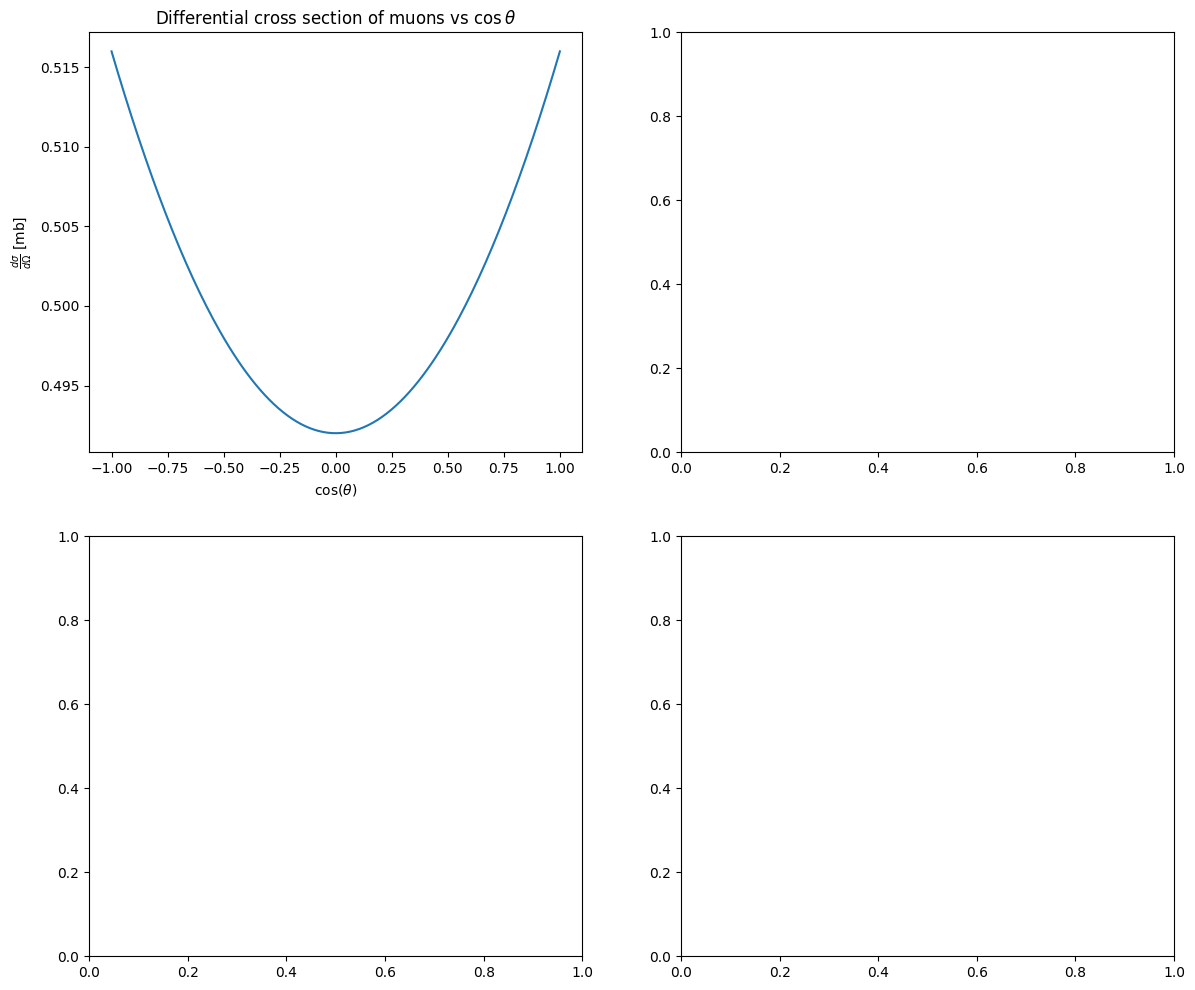

In [165]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 12))

cos_linspace = np.linspace(-1, 1, 200, endpoint=True)
ax1.plot(cos_linspace, cross_section_norm(s, cos_linspace))
ax1.set_xlabel(r"$\cos(\theta)$")
ax1.set_ylabel(r'$\frac{d\sigma}{d\Omega} \;[\mathrm{mb}]$')
ax1.set_title(r"Differential cross section of muons vs $\cos \theta$")

h1 = ax2.hist2d(v, phi, bins=100, cmap='plasma')
ax2.set_xlabel(r"$\cos{\theta}$")
ax2.set_ylabel(r"$\phi$ [rad]")
ax2.set_title(r"Monte Carlo: azimuthal angle $\phi$ vs $\cos\theta$")
fig.colorbar(h1[3], ax=ax2, label='Density')

theta_linspace = np.linspace(0, np.pi, 200, endpoint=True)
ax3.plot(theta_linspace, cross_section_norm(s, np.cos(theta_linspace)) * conversion_factor)
ax3.set_xlabel(r"$\theta$ [rad]")
ax3.set_ylabel(r'$\frac{d\sigma}{d\Omega} \;[\mathrm{mb}]$')
ax3.set_title(r"Differential cross section of muons vs scattering angle")

h2 = ax4.hist2d(np.arccos(v), phi, bins=100, cmap='plasma')
ax4.set_xlabel(r"$\theta$ [rad]")
ax4.set_ylabel(r"$\phi$ [rad]")
ax4.set_title(r"Monte Carlo: azimuthal angle $\phi$ vs scattering angle $\theta$")
fig.colorbar(h2[3], ax=ax4, label='Density')

plt.show() 

## Lorentz boost from the Center-of-Mass frame to the Laboratory frame

$ E_{e^+}=\frac{s-2m_e^2}{2m_e}$

$p_{e^+}=\sqrt{E_{e^+}^2-m_e^2}$

$\beta=\frac{p_{e^+}}{E_{e^+}+m_e}=\frac{v}{c}$

$\gamma=\frac{E_{e^+}+m_e}{\sqrt {s}}=\frac{1}{\sqrt{1-\beta^2}}$

$p_{\mu}=\sqrt{\frac{s}{4}-m_{\mu}^2}$

$p_{x,CM}=p_{\mu}\sin\theta\cos\phi$

$p_{y,CM}=p_{\mu}\sin\theta\sin\phi$

$p_{z,CM}=p_{\mu}\cos\theta$

$E_{CM}=\frac{\sqrt{s}}{2}$

$ E_{lab} = \gamma (E_{CM}+\beta p_{z,CM})$

$ p_{z,lab} = \gamma(p_{z,CM}+\beta E_{CM})$

$ p_{x,lab} = p_{x,CM}$

$ p_{y,lab} = p_{y,CM}$

<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1543916/3804793478.py:38: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$ E_{\mu}$ [GeV]")


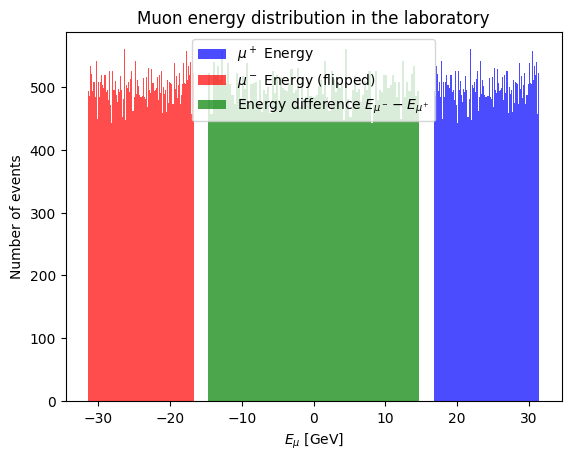

In [ ]:
# Positron energy and momentum in the lab frame
E_pos = (s - 2 * mass_e**2) / (2 * mass_e)
p_pos = np.sqrt(E_pos**2 - mass_e**2)

# Lorentz factors for boost from CM to lab
gamma = (E_pos + mass_e) / np.sqrt(s)
beta = p_pos / (E_pos + mass_e)

# Muon momentum in CM frame
p_mod = np.sqrt(s/4 - mass_mu**2)
px_cm_1 = p_mod * np.sqrt(1 - v**2) * np.cos(phi)
py_cm_1 = p_mod * np.sqrt(1 - v**2) * np.sin(phi)
pz_cm_1 = p_mod * v
E_cm_1 = np.sqrt(s)/2

px_cm_2 = -1 * p_mod * np.sqrt(1 - v**2) * np.cos(phi)
py_cm_2 = -1 * p_mod * np.sqrt(1 - v**2) * np.sin(phi)
pz_cm_2 = -1 * p_mod * v
E_cm_2 = np.sqrt(s)/2

# Boost muon momenta to lab frame
px_lab_1 = px_cm_1
py_lab_1 = py_cm_1
pz_lab_1 = gamma * (pz_cm_1 + beta * E_cm_1)
E_lab_1 = gamma * (E_cm_1 + beta * pz_cm_1)

px_lab_2 = px_cm_2
py_lab_2 = py_cm_2
pz_lab_2 = gamma * (pz_cm_2 + beta * E_cm_2)
E_lab_2 = gamma * (E_cm_2 + beta * pz_cm_2)

# Plot histograms of muon energies in the lab frame
plt.hist(E_lab_1, bins=100, alpha=0.7, color='blue', label=r"$\mu^+$ Energy")
plt.hist(-1.0 * E_lab_2, bins=100, alpha=0.7, color='red', label=r"$\mu^-$ Energy (flipped)")
plt.hist(E_lab_2 - E_lab_1, bins=100, alpha=0.7, color='green', label=r"Energy difference $E_{\mu^-}-E_{\mu^+}$")

plt.title("Muon energy distribution in the laboratory")
plt.xlabel("$ E_{\mu}$ [GeV]")
plt.ylabel("Number of events")
plt.legend()
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1543916/3952291708.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.title("$\mu^+$ angular distribution in the laboratory")


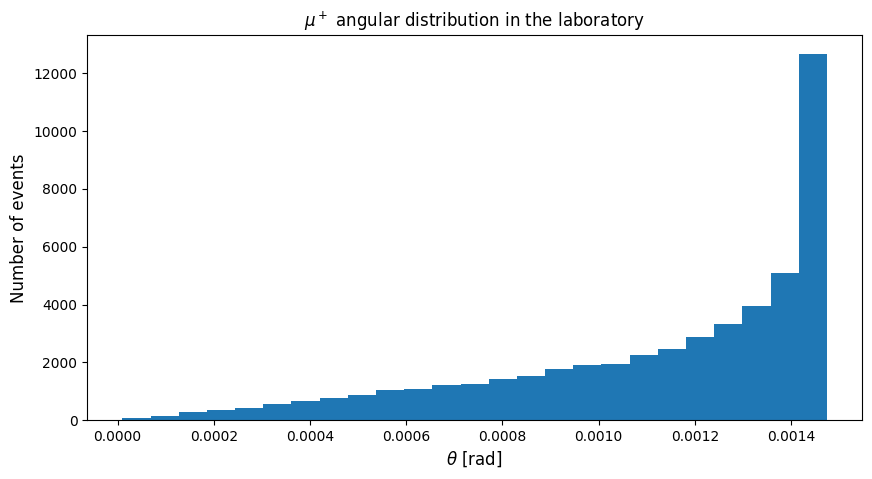

In [ ]:
# Histogram of the angular distribution of mu+ in the lab frame
plt.figure(figsize=(10, 5)) 
plt.hist(np.arccos(pz_lab_1 / np.sqrt(px_cm_1 ** 2 + py_cm_1 ** 2 + pz_lab_1 ** 2)), bins=25)
plt.ylabel("Number of events", fontsize=12)
plt.xlabel(r"$\theta$ [rad]", fontsize=12)
plt.title("$\mu^+$ angular distribution in the laboratory")
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1543916/1139071563.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.title("$\mu^-$ angular distribution in the laboratory")


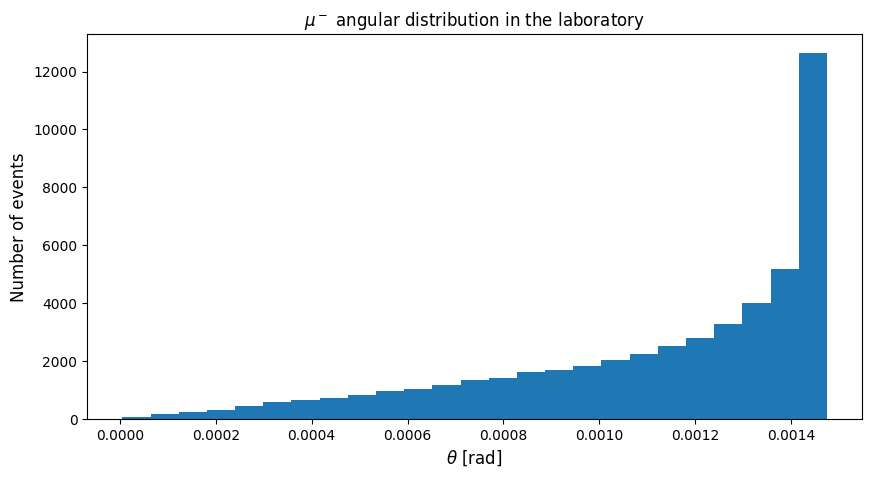

In [ ]:
# Histogram of the angular distribution of mu- in the lab frame
plt.figure(figsize=(10, 5)) 
plt.hist(np.arccos(pz_lab_2 / np.sqrt(px_cm_2 ** 2 + py_cm_2 ** 2 + pz_lab_2 ** 2)), bins=25)
plt.ylabel("Number of events", fontsize=12)
plt.xlabel(r"$\theta$ [rad]", fontsize=12)
plt.title("$\mu^-$ angular distribution in the laboratory")
plt.show()

## Production of the synthetic dataset

In [ ]:
# Save the data 
data = np.column_stack([E_lab_1, px_lab_1, py_lab_1, pz_lab_1, E_lab_2, px_lab_2, py_lab_2, pz_lab_2])
np.savetxt("muons_lab.txt", data)

column_names = ["E_mu+_lab", "px_mu+_lab", "py_mu+_lab", "pz_mu+_lab", "E_mu-_lab", "px_mu-_lab", "py_mu-_lab", "pz_mu-_lab"]
df = pd.read_csv("muons_lab.txt",sep=r'\s+', names=column_names)
df

,E_mu+_lab,px_mu+_lab,py_mu+_lab,pz_mu+_lab,E_mu-_lab,px_mu-_lab,py_mu-_lab,pz_mu-_lab
0,19.131333,-0.004042,-0.024639,19.131025,29.040863,0.004042,0.024639,29.040660
1,25.459095,-0.026680,0.019810,25.458854,22.713101,0.026680,-0.019810,22.712831
2,24.234103,0.021334,-0.026242,24.233849,23.938093,-0.021334,0.026242,23.937836
3,30.853809,-0.004210,-0.012443,30.853625,17.318387,0.004210,0.012443,17.318060
4,24.419474,-0.031433,0.012406,24.419223,23.752721,0.031433,-0.012406,23.752462
...,...,...,...,...,...,...,...,...
49934,30.549722,0.004962,0.015274,30.549535,17.622474,-0.004962,-0.015274,17.622150
49935,30.500496,-0.008181,-0.014298,30.500309,17.671700,0.008181,0.014298,17.671376
49936,17.046641,0.008356,0.004809,17.046310,31.125555,-0.008356,-0.004809,31.125374
49937,19.735364,0.008249,-0.025974,19.735063,28.436832,-0.008249,0.025974,28.436622


## Event weight for one week of data taking

In [ ]:
#total cross section integrating over solid angle
cross_section_tot = ((2 * np.pi * alpha**2) / (3 * s)) * beta * (3 - beta**2) * conversion_factor
print('The total cross section is:', cross_section_tot, 'mbarn')

The total cross section is: 0.0017652124197166845 mbarn


In [ ]:
d = 3                       # cm, target thickness
rate = 10**6                # Hz, event rate

uma = 1.660539e-24          # atomic mass unit in grams
B = 9.0121831               # atomic weight of Beryllium in uma
rho = 1.845                 # density of Beryllium in g/cm^3
n_be = rho / (uma * B)      # atomic number density of Beryllium

# Probability of interaction (convert cross section from mbarn to cm^2)
P = n_be * d * cross_section_tot * 10**(-27)       

T = 7 * 24 * 3600           # seconds, total measurement time

# Total number of interactions
E = T * rate * P

# Conversion factor per event
weight = E / len(v)

print(E)
print(len(v))

print('The conversion factor is:', weight)

394863.7770155121
49939
The conversion factor is: 7.9069219851321035


## Beam transverse profile and energy spread simulation

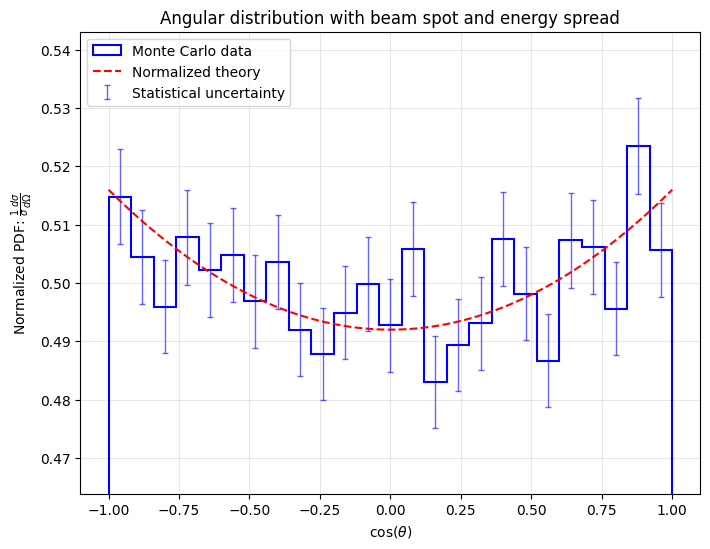

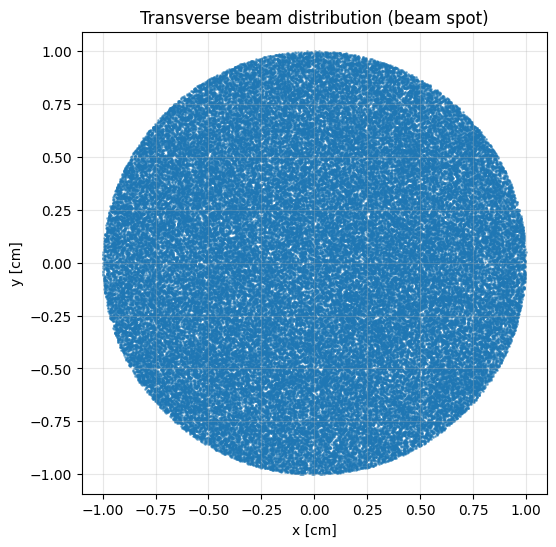

In [ ]:
# Random azimuthal angles and radial positions for the beam spot
R = 1.0  
alpha = np.random.uniform(0, 2*np.pi, n)      
rho = R * np.sqrt(np.random.uniform(0,1,n))   
x = rho * np.cos(alpha)                        
y = rho * np.sin(alpha)                        

# Beam energies with Gaussian spread
sigmaE = 0.5                                  # width of energy spread
E = np.random.normal(beam_energy, sigmaE, n) 

m_e = 0.000511  # GeV, electron mass
s_distr = 2 * m_e * (E + m_e)  # invariant s in lab frame

# Monte Carlo generation of muon angular distribution
u_new = np.random.uniform(-1, 1, n)  
r_new = np.random.uniform(0, cross_section_norm(s_distr, 1), n)  
v_new = u_new[r_new < cross_section_norm(s_distr, u_new)]         


plt.figure(figsize=(8, 6))

# Monte Carlo histogram (normalized)
plot_data(v_new)

# Normalized theoretical curve
s_mean = np.mean(s_distr)  # reference theoretical curve
plot_theory(s_mean)

plt.xlabel(r"$\cos(\theta)$")
plt.ylabel(r"Normalized PDF: $\frac{1}{\sigma}\frac{d\sigma}{d\Omega}$")
plt.title(r"Angular distribution with beam spot and energy spread")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot of the beam spot (x, y)
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=1, alpha=0.5)
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title("Transverse beam distribution (beam spot)")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.show()

## Nominal beam energy with energy loss in the target

In [ ]:
# Threshold energy to produce muons
E_th = ((2*mass_mu)**2 - 2 * m_e**2) / (2*m_e)  # GeV

# Target parameters
L = 6.0   # target length in cm
X0 = 35.3 # radiation length of Be in cm
E0 = E_th * np.exp(L / X0)
print(f"Nominal beam energy: {E0:.2f} GeV")

z = np.random.uniform(0, L, n)  # random position along the target
E_beam = E0 * np.exp(-z / X0)   # actual energy at position z

data1 = np.column_stack([x, y, z, E_beam])
np.savetxt("simulated_muon_beam.txt", data1)
column_names1 = ["x_cm", "y_cm", "z_cm", "E_beam_GeV"]
df_beam = pd.read_csv("simulated_muon_beam.txt", sep=r'\s+', names=column_names1)
df_beam

Nominal beam energy: 51.79 GeV


,x_cm,y_cm,z_cm,E_beam_GeV
0,0.937916,-0.097832,0.377613,51.237022
1,-0.021802,0.786746,4.094780,46.116010
2,-0.321084,0.663381,4.018272,46.216068
3,0.582729,-0.569871,5.460876,44.365430
4,-0.742767,-0.143579,0.476402,51.093833
...,...,...,...,...
99995,0.124614,-0.549629,2.018366,48.910011
99996,0.508115,-0.394393,0.395799,51.210632
99997,-0.250823,0.962507,2.177704,48.689737
99998,-0.534945,-0.782517,5.663751,44.111186


## Position-dependent Center-of-Mass energy in the target

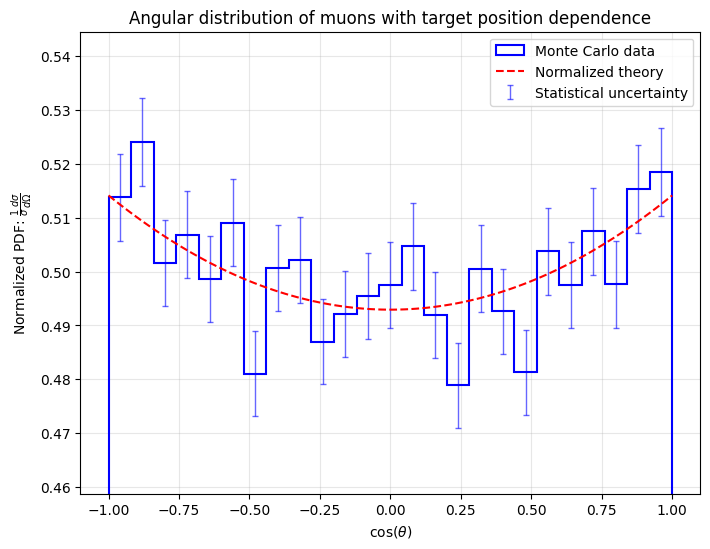

In [ ]:
# Generate angles in the CM frame using s_z
s_z = 2 * m_e**2 + 2 * m_e * E_beam

u_z = np.random.uniform(-1, 1, n)
r_z = np.random.uniform(0, cross_section_norm(s_z, 1), n)
v_z = u_z[r_z < cross_section_norm(s_z, u_z)]

plt.figure(figsize=(8, 6))

# Monte Carlo histogram (normalized)
plot_data(v_z)

# Normalized theoretical curve
s_z_mean = np.mean(s_z)  # reference theoretical curve
plot_theory(s_z_mean)

plt.xlabel(r"$\cos(\theta)$")
plt.ylabel(r"Normalized PDF: $\frac{1}{\sigma}\frac{d\sigma}{d\Omega}$")
plt.title(r"Angular distribution of muons with target position dependence")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Comparison with Babayaga simulation

In [ ]:
#def distr_rel(beta, cos):
#    return 3 * (2 - beta**2 + ( beta**2) * cos**2) / (4 * (3 - beta**2))

def plot_babayaga(file_path, sqrt_s):
    cos_theta_list = []
    weights_list = []
    
    with open(file_path, 'r') as f:
        lines = f.readlines()
        
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if line.startswith('# EVENT N.'):
            weights_list.append(float(lines[i+1].strip()))
            n_particles = int(lines[i+2].strip())
            
            # Leggiamo il primo muone (solitamente la riga i+3)
            # Formato riga: E px py pz
            muon_data = lines[i+3].split()
            pz = float(muon_data[3])
            energy = float(muon_data[0])
            
            # Calcolo cos(theta) = pz / |p|
            # Per muoni ultra-relativistici |p| approx E, 
            # altrimenti usiamo la norma del vettore p_x, p_y, p_z
            px = float(muon_data[1])
            py = float(muon_data[2])
            p_norm = np.sqrt(px**2 + py**2 + pz**2)
            
            if p_norm > 0:
                cos_theta_list.append(pz / p_norm)
            
            # Salta al prossimo evento
            i += 3 + n_particles
        else:
            i += 1

    # Disegna l'istogramma e salva i valori dei bin
    counts, bins, _ = plt.hist(cos_theta_list, bins=25, density=True, weights=weights_list, range=(-1, 1), 
                               histtype='step', color='orange', label='Babayaga data', linewidth=1.5)

    plt.title((r'Angular distribution $e^+ e^- \to \mu^+ \mu^-$ at $\sqrt{s}=$') + str(sqrt_s) + ' GeV')
    plt.xlabel(r'$\cos(\theta)$')
    plt.ylabel('Normalized PDF')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend()
    
    plt.show()


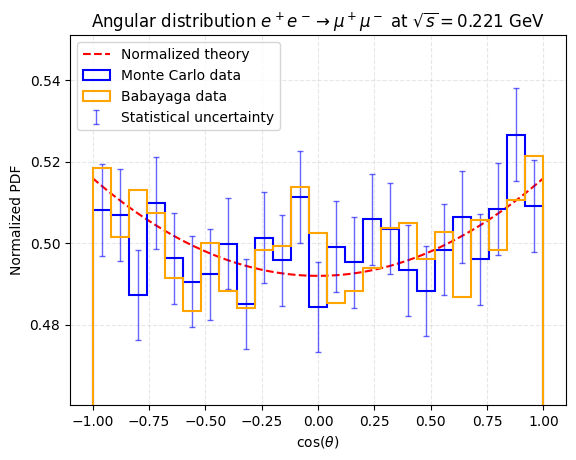

In [ ]:
plot_theory(s)
plot_data(v)
plot_babayaga('ResultsBabaYaga/run_221_tree_10e5/events.dat', sqrt_s=0.221)

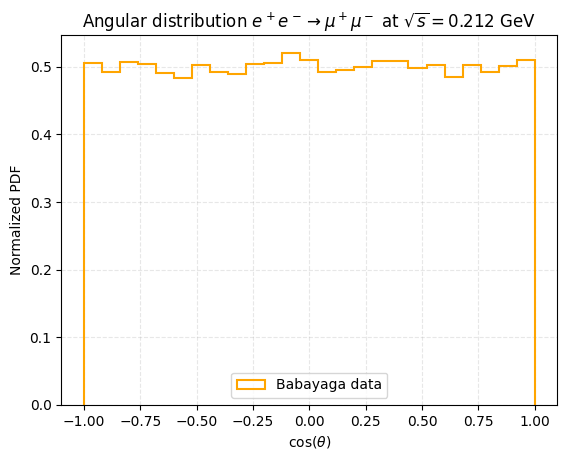

In [ ]:
plot_babayaga('ResultsBabaYaga/run_212_tree_10e5/events.dat', sqrt_s=0.212)